In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/pia222sk20/python_src/refs/heads/main/data/tellecom.csv'
df = pd.read_csv(url)
df.head()

In [ ]:
df.info()
# 3개의 항목을 제외하고 다 object 상태
# Totalcharges 의 경우엔 숫자이여야 되는 듯한데, object상태이다. 그 이유를 알아보자. 

In [ ]:
# 'Totalcharges' 컬럼에서 숫자형태의 문자가 아닌값을 결측치 처리한다.
# 해당 컬럼의 기본 타입을 파악해보기.
type(df['TotalCharges'][1])
# 문자열 형태, 결측치로 처리가 되어야 할값이 문자열인것으로 예상이 된다.

# 문자열 형태의 어떤 값 을 추출해보기
# pd.to_numeric(df['TotalCharges'])
# ValueError: Unable to parse string " " at position 488
# 어떤 값을 변환할수없는지 오류가 나게해서 항목내용과 위치를 알아낼수있다.
# 알아보니, " "빈공간이 결측치 인것으로 확인된다.
type(df['TotalCharges'][488])
# 확실히 문자열인것으로 확인된다.
# 문자열 전용 nan 변환 명령어 만들어 보기. ^

In [ ]:
# 간단하게
# 숫자로 변환이 불가한 항목들을 NaN으로 변환한다.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

# to_numeric()
# 위치: pandas 모듈 함수
# 기능: Series나 배열 같은 데이터를 숫자형으로 변환 시도
# 옵션:
# errors='raise' (기본): 변환 불가능하면 에러 발생
# errors='coerce': 변환 불가능한 값은 NaN으로 처리
# errors='ignore': 변환 불가능하면 원래 값 유지

df.info()

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

# 매트릭스 그래프
msno.matrix(df)
plt.show()

In [ ]:
df.isna().mean()
# TotalCharges 결측치 비율은 0.001562 -> 해당 결측치 row(행)데이터를 삭제
df = df.dropna(subset=['TotalCharges'])
print(len(df))

In [ ]:
df['Churn'].unique()

In [ ]:
# 이탈여부 Churn --> yes no   1 0 으로 변경  분석하기 용이함(ex true/false, 남/여)
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})
df['Churn']
# df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})

# 값 변경 → map() 또는 replace()
# map의 경우 유의사항 잘못입력하면 nan값이 생성될수있다.
# replace의 경우 유의사항 ? ^

# 컬럼 이름 변경 → rename(columns={...})

# transform()

In [ ]:
df.head()

In [ ]:
# 이탈 고객의 현황
# countplot
import matplotlib.pyplot as plt
import seaborn as sns

f,ax = plt.subplots(1,2,figsize=(12,5))

sns.countplot(data=df,x='Churn',ax=ax[0]) # data는 df를 참고하고, x값은 Churn의 값으로
df['Churn'].value_counts()
ax[1].pie(x=df['Churn'].value_counts(),autopct='%1.1f%%')
ax[1].legend(['0','1'])
# plt.pie # <function matplotlib.pyplot.pie(x: 'ArrayLike', *, explode: 'ArrayLike | None' = None, labels: 'Sequence[str] | None' = None, colors: 'ColorType | Sequence[ColorType] | None' = None, autopct: 'str | Callable[
# 저런거 안뜨게 하는 그래프 조회 명령어
plt.show()
# 계약종류, 가입기간


In [ ]:
# 타깃이 되는 변수와 같이 영향을 미치는 다른 변수와의 관계
df.head()

In [ ]:
# 강사님 풀이
# 비용에 따른 가입 유지 여부 확인
# 비용구간을 세가지 구간으로 나누기
# TotalCharges 3등분해서 (H,M,L) -> 새로운 컬럼에 추가
df['TotalCharges_Rank'] = pd.qcut(df['TotalCharges'], q=3, labels=['L','M','H'])
df.tail()
# 새로운컬럼별 가입여부에대한 groupby 를 해서 시각화 까지
sns.countplot(data=df, x='TotalCharges_Rank',hue='Churn')

In [ ]:
# 학생 풀이 1트 ^
# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "C:\김지은\파이썬_src\pandas-data-analysis\part4\data\malgun.ttf"   # 폰트파일의 위치
                                  # Windows - Fonts
font_name = font_manager.FontProperties(fname=font_path).get_name()
# .get_name() : 폰트가 시스템에서 인식하는 이름을 가져옵니다.
# get_name() → .ttf 파일에서 폰트 이름(패밀리명) 추출
# 그 이름을 family에 넣으면 → matplotlib이 해당 폰트를 기본으로 사용
print(font_name) # Malgun Gothic
rc('font', family=font_name)

In [ ]:
# TotalCharges (H,M,L)
import numpy as np
cnt,bins = np.histogram(df['TotalCharges'],bins=3)
print(cnt, bins)
labels = ['L','M','H']
df['Cost'] = pd.cut(df['TotalCharges'],
    bins = bins,
    labels = labels
)
####################
# 비용별, Churn=1 인 데이터 히스토그램이 조회되었다..
# ChurnCost = df.groupby('Cost')['Churn'].sum()
# ChurnCost.plot(kind='bar')
# plt.show()
# 비용별, Churn=1,Churn=0인 데이터 히스토그램을 조회로 수정 요청
####################
# gpt 0 기본
# Churn=1과 Churn=0을 각각 계산
Churn1 = df[df['Churn']==1].groupby('Cost')['Churn'].count()
Churn0 = df[df['Churn']==0].groupby('Cost')['Churn'].count()

# 두 데이터를 하나의 데이터프레임으로 합치기
ChurnCost = pd.DataFrame({'Churn0': Churn0, 'Churn1': Churn1})

# 막대 그래프
ChurnCost.plot(kind='bar')
plt.ylabel('Count')
plt.title('비용별 이용자 유지여부')
plt.show()

# gpt 1 심화
# Cost 구간별 Churn 0과 1 개수
# ChurnCost = df.groupby(['Cost','Churn']).size().unstack(fill_value=0)

# # 막대 그래프로 시각화
# ChurnCost.plot(kind='bar', stacked=False)
# plt.ylabel('Count')
# plt.title('Cost 구간별 Churn 0/1 구분')
# plt.show()
# https://chatgpt.com/s/t_68dcd1ccf7848191aad8747f058fc541

In [ ]:
# 계약 종류(Contract)에 따른 고객 분포
# 가입기간(tenure)분포
# 계약 종류에 따른 이탈률
# 가입 기간에 따른 이탈률
# 월 요금에 따른 이탈률
# 상관관계 분석(Correlation Analysis)

<Axes: xlabel='Contract', ylabel='count'>

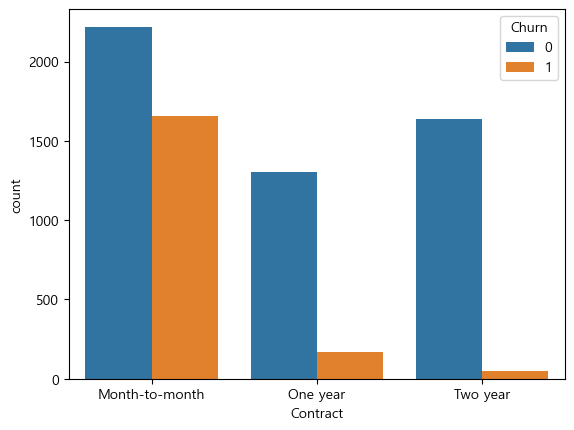

In [52]:
# 강사님 풀이
# 계약 종류(Contract)에 따른 고객 분포
sns.countplot(data=df,x='Contract', hue='Churn')
# 가입 기간(tenure) 분포
# 계약 종류에 따른 이탈률
# 가입 기간에 따른 이탈률 -  ㅇ
# 월 요금에 따른 이탈률
# 상관관계 분석 (Correlation Analysis) - ㅇ

<Axes: xlabel='Churn', ylabel='tenure'>

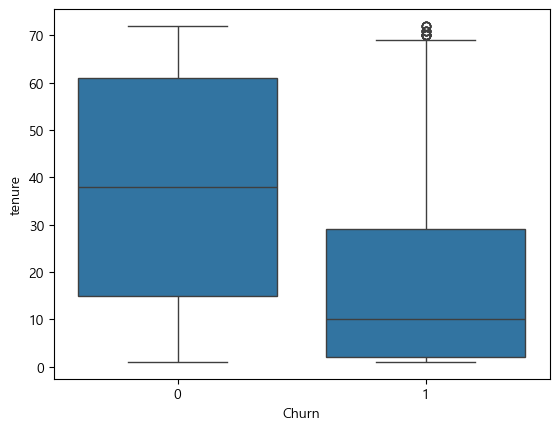

In [53]:
sns.boxplot(data=df, x='Churn', y='tenure')

In [ ]:
# 학생 풀이 1트 ^ (완)
# Contract에서의 계약 종류 확인
df['Contract'].unique()
# array(['Month-to-month', 'One year', 'Two year'], dtype=object)

# 계약 종류별 고객 분포
Contract1 = df[df['Contract']=='Month-to-month'].count()
Contract2 = df[df['Contract']=='One year'].count()
Contract3 = df[df['Contract']=='Two year'].count()

# 세 데이터를 하나의 데이터프레임으로 합치기
Contract = pd.DataFrame({'Month-to-month': Contract1, 'One year': Contract2, 'Two year': Contract3})

# 계약종류에 따른 이탈률
sns.countplot(data=df, x='Contract',hue='Churn')

In [ ]:
# 월요금에 따른 이탈률 MonthlyCharges - Churn

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

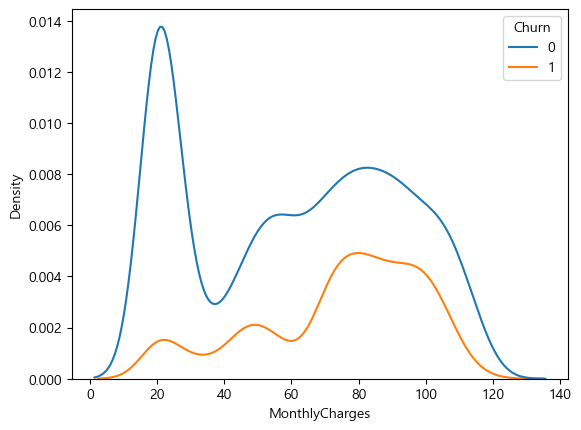

In [54]:
# 강사님 풀이
# 월 요금에 따른 이탈률
# df[['MonthlyCharges','Churn']]
sns.kdeplot(data=df, x='MonthlyCharges',hue='Churn')

In [ ]:
df.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customerID         7032 non-null   object  
 1   gender             7032 non-null   object  
 2   SeniorCitizen      7032 non-null   int64   
 3   Partner            7032 non-null   object  
 4   Dependents         7032 non-null   object  
 5   tenure             7032 non-null   int64   
 6   PhoneService       7032 non-null   object  
 7   MultipleLines      7032 non-null   object  
 8   InternetService    7032 non-null   object  
 9   OnlineSecurity     7032 non-null   object  
 10  OnlineBackup       7032 non-null   object  
 11  DeviceProtection   7032 non-null   object  
 12  TechSupport        7032 non-null   object  
 13  StreamingTV        7032 non-null   object  
 14  StreamingMovies    7032 non-null   object  
 15  Contract           7032 non-null   object  
 16  PaperlessBi

<Axes: xlabel='MonthlyCharges', ylabel='count'>

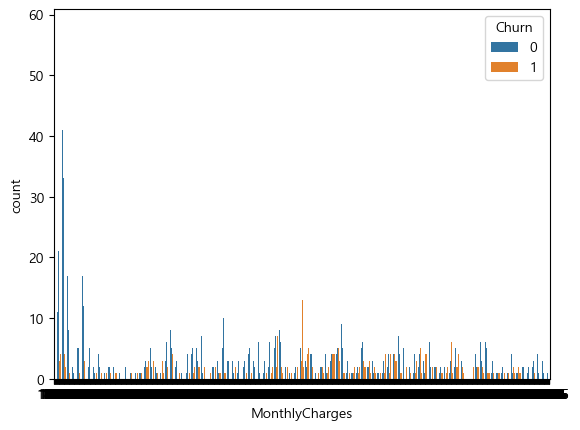

In [ ]:
# 학생 풀이 1트 ^ 데이터의 특성?을 알고 적절한 그래프 유형 선택할줄 알기
# x축은 비용으로, 이탈 여부는 두가지의 그래프로 표현
sns.countplot(data=df, x='MonthlyCharges',hue='Churn')

In [ ]:
# 상관관계
df.info()
# df 수치형 데이터...(문자열이 아닌) 들로만 구성을 해서 .corr() 적용

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customerID         7032 non-null   object  
 1   gender             7032 non-null   object  
 2   SeniorCitizen      7032 non-null   int64   
 3   Partner            7032 non-null   object  
 4   Dependents         7032 non-null   object  
 5   tenure             7032 non-null   int64   
 6   PhoneService       7032 non-null   object  
 7   MultipleLines      7032 non-null   object  
 8   InternetService    7032 non-null   object  
 9   OnlineSecurity     7032 non-null   object  
 10  OnlineBackup       7032 non-null   object  
 11  DeviceProtection   7032 non-null   object  
 12  TechSupport        7032 non-null   object  
 13  StreamingTV        7032 non-null   object  
 14  StreamingMovies    7032 non-null   object  
 15  Contract           7032 non-null   object  
 16  PaperlessBi

In [ ]:
# 학생 풀이 1트
# df 수치형 데이터...(문자열이 아닌) 들로만 구성을 해서 .corr() 적용
corr_dataframe = pd.DataFrame({'SeniorCitizen ': df['SeniorCitizen'], 'tenure': df['tenure'],
                               'MonthlyCharges':df['MonthlyCharges'], 'TotalCharges':df['TotalCharges'],
                               'Churn':df['Churn']})
cd = corr_dataframe.corr()
cd
# 그래프로 만들어낼수는 있지만 직관적으로 잘 안보인다.

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150541,-0.354049,0.192858,-0.199484,1.000000


In [56]:
# 강사님 풀이
df.describe().columns
df.loc[:, df.describe().columns].corr()
# 대각선 방향으로 보여줄 그래프 기준 세우기
# 가입기간과 월별비용의 상관관계

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150541,-0.354049,0.192858,-0.199484,1.000000


In [ ]:
# 상관계수 ^
# 'pearson', 'kendall', 'spearman'
# pearson : 변수들 사이에 선형관계
# spearman : 선형관계가 아닌 비선형 관계, 이상치가 있을때, 순위로 바꾸면 이상치의 영향이 크게 줄어든다.
    # 순서데이터 : 만족도 등과 같이 값자체가 순서인 데이터
# kendall : 데이터 샘플이 적을때 일치하는 상과 불일치하는 쌍의 개수

In [59]:
df.describe(include='object')
remove_cols = ['customerID']

In [ ]:
# 수치형 데이터 추출
# 상관계수의 값을 통해 값이 높은 변수들은 한개만 선택(제외)
# -> 두 변수끼리 연관성이 높으면 하나는 제외하라
# 고객 아이디는 제거
# preprocess_df 라고 저장

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


In [ ]:
# 강사님 풀이
preprocess_df = df.loc[:,df.describe().columns].drop(columns=['TotalCharges'])
preprocess_df.head()

In [ ]:
# 학생 풀이 1트
# 수치형 데이터 추출
numeric_data= df.describe(include='int'or'float')

# 계산하기위해 안에 모든 데이터 속성을 float로 변경
numeric_data = numeric_data.astype(int)

# 상관계수 비교로 불필요한 열은 추려내고 삭제
numeric_data.corr()
# SeniorCitizen 과 Churn이 동일
# Churn을 남기는 걸로
numeric_data = numeric_data.drop('SeniorCitizen',axis=1)

numeric_data

# str중에서 숫자값을 가진 게 없는지 검토 및 추가하는 방법 gpt

# 수치형 데이터만 선택
# numeric_data = df.select_dtypes(include=['int64', 'float64'])

# 문자열 데이터만 선택 -> object 객체중에는 문자열뿐만아니라 다양한 객체가 들어갈 수있다.
# df['mixed'].apply(type) 이런식으로 직접 타입을 확인한다.
string_data = df.select_dtypes(include=['object'])

# 그냥 가볍게 읽어보자.
# 2 문자열 중에서 숫자로 변환 가능한 컬럼 찾기
for col in string_data.columns:
    # 모든 값이 숫자로 변환 가능한지 검토
    if string_data[col].str.isnumeric().all():
        print(f"{col} 컬럼은 숫자로 변환 가능")
# 3️ 숫자로 변환 후 수치형 데이터에 추가
for col in string_data.columns:
    # 숫자로 변환 가능한 값만 float으로 변환
    numeric_data[col] = pd.to_numeric(string_data[col], errors='coerce')

# 상관계수로 연관성이 높은 항목들을 구분하는 방법 ^

,tenure,Churn
count,7032,7032
mean,32,0
std,24,0
min,1,0
25%,9,0
50%,29,0
75%,55,1
max,72,1


In [ ]:
X = preprocess_df.iloc[:,:-1]
Y = preprocess_df['Churn']

In [ ]:
import numpy as np
split_indexs = int(np.round(len(X)*0.8))
train_x = X[ : split_indexs]
test_x = X[split_indexs : ]
train_y = Y[ : split_indexs]
test_y = Y[split_indexs : ]

len(train_x), len(train_y), len(test_x), len(test_y)